# 🧠 K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is one of the **simplest and most intuitive machine learning algorithms**.

It is used for:
- ✅ Classification (most common)
- ✅ Regression

---

## 💡 Core Idea

👉 “Similar data points are close to each other”

KNN works by:
1. Taking a new data point
2. Finding the **K closest points** from training data
3. Assigning the label based on **majority voting**

---

## 📌 Example

Imagine:
- You want to classify a fruit 🍎🍊
- You look at its **nearest neighbors**
- If most neighbors are apples → it's an apple

---

## 🎯 Why Learn KNN?

- Very beginner-friendly
- Builds strong intuition about ML
- Helps understand distance-based learning

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 📊 Dataset: Iris Dataset

We are using the famous **Iris dataset** 🌸

It contains:
- 3 flower classes
- 4 features:
  - Sepal length
  - Sepal width
  - Petal length
  - Petal width

In [2]:
data = load_iris()

X = data.data
y = data.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (150, 4)
Target shape: (150,)


# 🔍 Why Split Data?

We split data into:
- Training set → model learns
- Testing set → model is evaluated

👉 This helps us measure real-world performance

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (120, 4)
Test size: (30, 4)


# ⚖️ Feature Scaling (Very Important ⚠️)

KNN is based on **distance calculation**.

👉 Problem:
If one feature has large values, it dominates the distance.

### ❌ Without Scaling:
- Height (cm): 180
- Weight (kg): 70  
→ Height dominates

### ✅ With Scaling:
- All features contribute equally

---

## 🧠 Rule:
👉 ALWAYS scale data before using KNN

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 🤖 Training the Model

We choose:
- K = 5 (common default)

👉 This means model looks at 5 nearest neighbors

In [5]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

# 🔮 Prediction

Now the model predicts labels for unseen data

In [6]:
y_pred = knn.predict(X_test)

# 📈 Evaluation

We evaluate using:
- Accuracy
- Classification Report
- Confusion Matrix

In [7]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [8]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



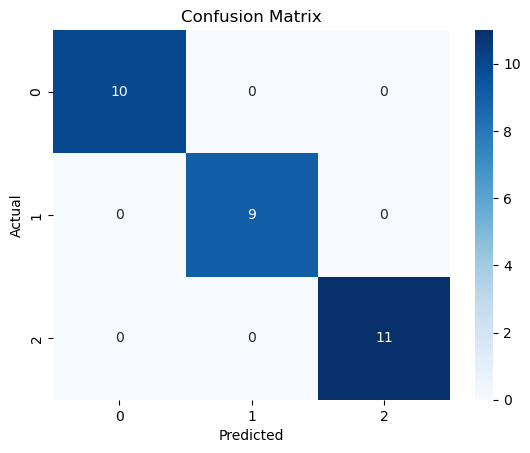

In [9]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ⚙️ Choosing the Best K Value

Choosing K is very important:

- 🔴 Small K → Overfitting (too sensitive to noise)
- 🔵 Large K → Underfitting (too generalized)

👉 We try multiple values and pick the best one

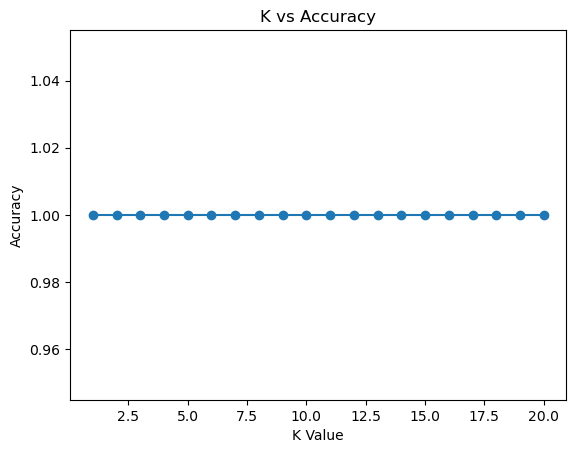

In [10]:
accuracies = []

k_values = range(1, 21)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    accuracies.append(acc)

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()

# 🧪 Distance Metrics

KNN uses distance to find neighbors.

Common metrics:
- Euclidean (default)
- Manhattan
- Minkowski

---

## 📌 Example

Euclidean distance:
👉 Straight-line distance

Manhattan distance:
👉 Grid-based distance (like city blocks)

---

## 💡 Try this:
Change metric and observe results

In [11]:
knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_manhattan.fit(X_train, y_train)

y_pred_manhattan = knn_manhattan.predict(X_test)

print("Manhattan Accuracy:", accuracy_score(y_test, y_pred_manhattan))

Manhattan Accuracy: 1.0


# ✅ Advantages
- Simple and intuitive
- No training phase (lazy learner)
- Works well for small datasets

# ❌ Disadvantages
- Slow for large datasets
- Sensitive to noise
- Requires scaling
- Memory intensive

# 🎯 Final Takeaways

- KNN is a **distance-based algorithm**
- It stores all training data (lazy learning)
- Performance depends on:
  - K value
  - Feature scaling
  - Distance metric

---

## 🚀 When to Use KNN?

✔ Small datasets  
✔ Pattern recognition  
✔ Baseline model  

---

## ❗ When NOT to Use?

❌ Large datasets  
❌ High-dimensional data  

---

👉 Master this, and you understand one of the most intuitive ML algorithms 💯